# Regressão Linear com PyTorch

## Objetivo

Este exemplo utiliza regressão linear para estimar o comprimento das sépalas da íris a partir do seu comprimento das pétalas.
Utiliza-se
- o cálculo do gradiente automático do PyTorch, porém
- a função de perda e
- atualização dos parâmetros é feita de forma explícita.
- A rede é criada com uma camada nn.Linear()

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinear_Otimizacao.png)

## Importação dos pacotes

In [54]:
# Instalar pacotes necessários (sem 'install', que não existe)
!pip install -q wheel setuptools packaging

# Instalar PyTorch moderno (com torchvision e torchaudio)
!pip install torch torchvision torchaudio

import torch

print("Versão do PyTorch:", torch.__version__)
print("CUDA disponível:", torch.cuda.is_available())


Versão do PyTorch: 2.8.0+cu126
CUDA disponível: False


In [55]:
%matplotlib inline
import matplotlib.pyplot as plt

import numpy as np
from sklearn.datasets import load_iris

import torch
from torch import nn, optim
from torch.autograd import Variable

torch.manual_seed(1234)

## Leitura dos dados

In [56]:
iris = load_iris()
data = iris.data[iris.target==1,::2]  # comprimento das sépalas e pétalas, indices 0 e 2

x_train = data[:,0:1].astype(np.float32)
y_train = data[:,1:2].astype(np.float32)

n_samples = x_train.shape[0]
print('x_train.shape:',x_train.shape, x_train.dtype)
print('y_train.shape:',y_train.shape, y_train.dtype)

print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train.shape: (50, 1) float32
y_train.shape: (50, 1) float32
x_train[:5]:
 [[7. ]
 [6.4]
 [6.9]
 [5.5]
 [6.5]]
y_train[:5]:
 [[4.7]
 [4.5]
 [4.9]
 [4. ]
 [4.6]]


### Normalização dos dados

In [57]:
x_train -= x_train.min()
x_train /= x_train.max()
y_train -= y_train.min()
y_train /= y_train.max()


In [58]:
print('x_train[:5]:\n', x_train[:5])
print('y_train[:5]:\n', y_train[:5])

x_train[:5]:
 [[1.        ]
 [0.71428573]
 [0.952381  ]
 [0.28571424]
 [0.7619048 ]]
y_train[:5]:
 [[0.80952376]
 [0.71428573]
 [0.90476197]
 [0.4761905 ]
 [0.7619048 ]]


In [59]:
x_train_bias = np.hstack([np.ones(shape=(n_samples,1)), x_train])

In [60]:
x_train_bias

array([[1.        , 1.        ],
       [1.        , 0.71428573],
       [1.        , 0.95238101],
       [1.        , 0.28571424],
       [1.        , 0.76190478],
       [1.        , 0.38095227],
       [1.        , 0.66666675],
       [1.        , 0.        ],
       [1.        , 0.80952376],
       [1.        , 0.14285702],
       [1.        , 0.047619  ],
       [1.        , 0.47619051],
       [1.        , 0.52380949],
       [1.        , 0.57142848],
       [1.        , 0.33333325],
       [1.        , 0.85714275],
       [1.        , 0.33333325],
       [1.        , 0.42857149],
       [1.        , 0.61904752],
       [1.        , 0.33333325],
       [1.        , 0.47619051],
       [1.        , 0.57142848],
       [1.        , 0.66666675],
       [1.        , 0.57142848],
       [1.        , 0.71428573],
       [1.        , 0.80952376],
       [1.        , 0.90476197],
       [1.        , 0.85714275],
       [1.        , 0.52380949],
       [1.        , 0.38095227],
       [1.

In [61]:
print('x_train_bias.shape:',x_train_bias.shape, x_train_bias.dtype)

x_train_bias.shape: (50, 2) float64


In [62]:
x_train_bias = torch.FloatTensor(x_train_bias)
y_train      = torch.FloatTensor(y_train)
print(y_train)

tensor([[0.8095],
        [0.7143],
        [0.9048],
        [0.4762],
        [0.7619],
        [0.7143],
        [0.8095],
        [0.1429],
        [0.7619],
        [0.4286],
        [0.2381],
        [0.5714],
        [0.4762],
        [0.8095],
        [0.2857],
        [0.6667],
        [0.7143],
        [0.5238],
        [0.7143],
        [0.4286],
        [0.8571],
        [0.4762],
        [0.9048],
        [0.8095],
        [0.6190],
        [0.6667],
        [0.8571],
        [0.9524],
        [0.7143],
        [0.2381],
        [0.3810],
        [0.3333],
        [0.4286],
        [1.0000],
        [0.7143],
        [0.7143],
        [0.8095],
        [0.6667],
        [0.5238],
        [0.4762],
        [0.6667],
        [0.7619],
        [0.4762],
        [0.1429],
        [0.5714],
        [0.5714],
        [0.5714],
        [0.6190],
        [0.0000],
        [0.5238]])


## Model

![alt text](https://raw.githubusercontent.com/vcasadei/images/master/RegressaoLinearNeuronio.png)

In [63]:
model = torch.nn.Linear(in_features=2, out_features=1, bias=False)

### Verificando a inicialização dos parâmetros

In [64]:
model.weight.data = torch.zeros(1,2)
torch.nn.init.uniform(model.weight.data, -0.1, 0.1)
model.weight

/tmp/ipython-input-2197199425.py:2: FutureWarning: `nn.init.uniform` is now deprecated in favor of `nn.init.uniform_`.
  torch.nn.init.uniform(model.weight.data, -0.1, 0.1)


Parameter containing:
tensor([[-0.0480, -0.0267]], requires_grad=True)

### Testando o predict da rede

In [65]:
xx = torch.ones((5,2))
xx

tensor([[1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.],
        [1., 1.]])

In [66]:
model(Variable(xx))

tensor([[-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747],
        [-0.0747]], grad_fn=<MmBackward0>)

## Treinamento

Epoch[20/100], loss: 0.022454
Epoch[40/100], loss: 0.021355
Epoch[60/100], loss: 0.021196
Epoch[80/100], loss: 0.021173
Epoch[100/100], loss: 0.021170


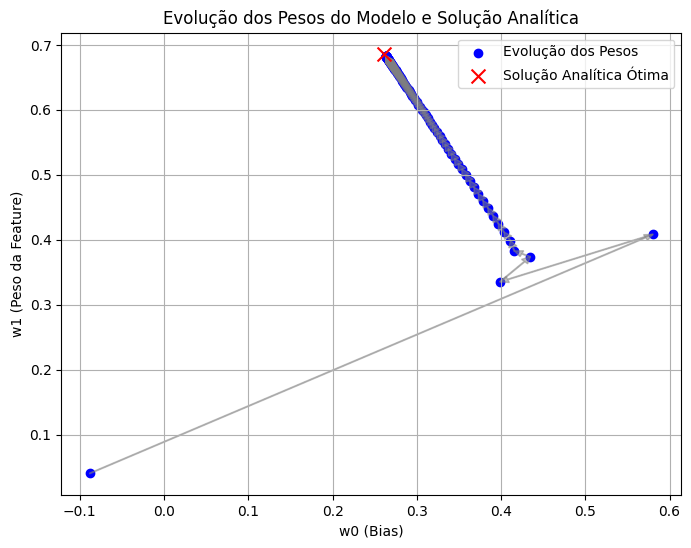

In [67]:
num_epochs = 100
learning_rate = 0.5

w0_list = []
w1_list = []

# Re-initialize model weights to ensure consistent starting point for evolution plot
# This ensures the plot starts from a fresh, randomized state.
model.weight.data = torch.zeros(1,2)
torch.nn.init.uniform_(model.weight.data, -0.1, 0.1) # Using uniform_ for modern PyTorch

for epoch in range(num_epochs):
    inputs = x_train_bias
    target = y_train

    # forward - predict
    out = model(inputs)

    #loss cálculo da função de perda
    loss = torch.pow(out - target, 2).mean()
    # print('loss:',loss.data.numpy()) # Removido para evitar poluir o output

    # backward propagation - cálculo gradiente
    loss.backward()

    # Store current weights before update
    w0_list.append(model.weight.data[0][0].item())
    w1_list.append(model.weight.data[0][1].item())

    # gradiente descendente
    model.weight.data = model.weight.data - learning_rate * model.weight.grad.data

    # zeragem parâmetros próximo cálculo do gradiente
    model.weight.grad.data.zero_()

    # verbose
    if (epoch+1) % 20 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'
              .format(epoch+1, num_epochs, loss.item()))


# Plotting the evolution of weights
plt.figure(figsize=(8, 6))
plt.scatter(w0_list, w1_list, c='blue', marker='o', label='Evolução dos Pesos')
w0_old = None
for i in range(len(w0_list)):
    if w0_old is not None:
        plt.arrow(w0_old, w1_old, w0_list[i] - w0_old, w1_list[i] - w1_old,
                  head_length=0.01, head_width=0.01, shape='full', color='gray',
                  length_includes_head=True, alpha=0.5)
    w0_old, w1_old = w0_list[i], w1_list[i]

# Add the optimal analytical solution
w_opt_0 = w_opt[0].item()
w_opt_1 = w_opt[1].item()
plt.scatter(w_opt_0, w_opt_1, c='red', marker='x', s=100, label='Solução Analítica Ótima')

plt.xlabel('w0 (Bias)')
plt.ylabel('w1 (Peso da Feature)')
plt.title('Evolução dos Pesos do Modelo e Solução Analítica')
plt.legend()
plt.grid(True)
plt.show()

## Avaliação

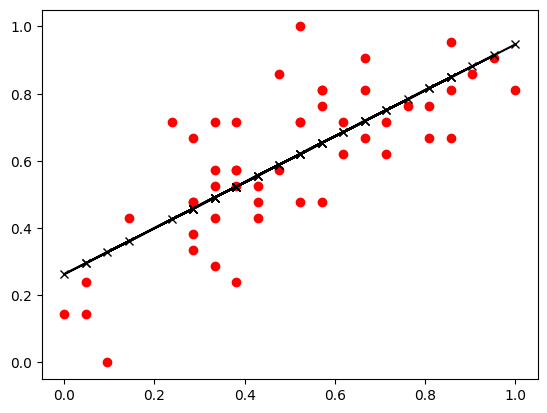

In [68]:
y_pred = model(Variable(x_train_bias))
plt.plot(x_train, y_train.numpy(), 'ro', label='Original data')
plt.plot(x_train, y_pred.data.numpy(), 'kx-', label='Fitting Line')
plt.show()

### Acessando os parâmetros

In [69]:
w_dic = model.state_dict()
w_dic

OrderedDict([('weight', tensor([[0.2629, 0.6835]]))])

### Parâmetros ótimos, solução analítica

In [70]:
x_bias = x_train_bias
y = y_train
x_bias_t = torch.t(x_bias)
w_opt = (torch.inverse(x_bias_t.mm(x_bias)).mm(x_bias_t)).mm(y)
print(torch.t(w_opt))

tensor([[0.2613, 0.6865]])


# Exercícios

- 1) Por que no final da varredura do laço de treinamento, a perda é impressa utilizando
   `loss.data[0]`? Por que precisa do `data` e por que precisa da indexação por zero?
   

O ajuste foi necessário porque a perda calculada com .mean() em PyTorch é um tensor escalar, sem dimensões. Nesse caso, não existe índice para acessar como em loss.data[0]. A forma correta de obter o valor numérico é usar loss.item(), que converte o tensor escalar em um número Python simples. Assim, o código roda sem erro e imprime corretamente a perda em cada época:

print('Epoch[{}/{}], loss: {:.6f}'.format(epoch+1, num_epochs, loss.item()))

Esse pequeno ajuste garante que o valor da perda seja exibido de forma segura e adequada durante o treinamento.

- 2) Calcule e imprima o valor da perda (MSE) fazendo o predict da rede com os pesos já
   treinados.

In [71]:
# Fazer o predict com os pesos treinados
y_pred_final = model(x_train_bias)

# Calcular a perda MSE
final_loss = torch.pow(y_pred_final - y_train, 2).mean()

# Imprimir o valor da perda
print(f"Perda (MSE) final com pesos treinados: {final_loss.item():.6f}")

Perda (MSE) final com pesos treinados: 0.021170


In [72]:
# Exemplo de demonstração
import torch

# Criando um tensor escalar (0-dimensional)
scalar_tensor = torch.tensor(10.5)
print(f"Tensor escalar: {scalar_tensor}")
print(f"Dimensões do tensor escalar: {scalar_tensor.dim()}")

# Tentando acessar com indexação (causa erro em tensors 0-dim)
print("Tentando scalar_tensor[0]...")
try:
    print(scalar_tensor[0])
except IndexError as e:
    print(f"  Erro esperado: {e}")

# Acessando o valor com .item() (método correto)
value_item = scalar_tensor.item()
print(f"Valor com .item(): {value_item} (tipo: {type(value_item)})")

# Acessando o valor com .data.numpy() (funciona, mas .item() é preferível para escalares)
value_numpy = scalar_tensor.data.numpy()
print(f"Valor com .data.numpy(): {value_numpy} (tipo: {type(value_numpy)})")

# Demonstração de um tensor 1-dimensional para comparação
vector_tensor = torch.tensor([10.5, 20.0])
print(f"\nTensor 1-dimensional: {vector_tensor}")
print(f"Dimensões do tensor 1-dimensional: {vector_tensor.dim()}")

# Acessando com indexação em um tensor 1-dimensional (funciona)
print(f"Acessando vector_tensor[0]: {vector_tensor[0]}")

# Forma correta de extrair valores individuais com .item()
print(f"vector_tensor[0].item(): {vector_tensor[0].item()}")
print(f"vector_tensor[1].item(): {vector_tensor[1].item()}")

# Se quiser todos os valores de uma vez, use .numpy()
print(f"vector_tensor.numpy(): {vector_tensor.numpy()} (tipo: {type(vector_tensor.numpy())})")


Tensor escalar: 10.5
Dimensões do tensor escalar: 0
Tentando scalar_tensor[0]...
  Erro esperado: invalid index of a 0-dim tensor. Use `tensor.item()` in Python or `tensor.item<T>()` in C++ to convert a 0-dim tensor to a number
Valor com .item(): 10.5 (tipo: <class 'float'>)
Valor com .data.numpy(): 10.5 (tipo: <class 'numpy.ndarray'>)

Tensor 1-dimensional: tensor([10.5000, 20.0000])
Dimensões do tensor 1-dimensional: 1
Acessando vector_tensor[0]: 10.5
vector_tensor[0].item(): 10.5
vector_tensor[1].item(): 20.0
vector_tensor.numpy(): [10.5 20. ] (tipo: <class 'numpy.ndarray'>)


- 3) Crie duas listas `w0_list` e `w1_list` para guardar a evolução dos valores dos parâmetros durante o laço de treinamento.
   Modifique o exemplo do gráfico tipo **scatter plot** para visualizar a variação
   dos parâmetros do modelo duas dimensões.
   Marque neste gráfico o valor ótimo do parâmetro dado pela solução
   analítica.

Epoch[20/100], loss: 0.021170
Epoch[40/100], loss: 0.021169
Epoch[60/100], loss: 0.021169
Epoch[80/100], loss: 0.021169
Epoch[100/100], loss: 0.021169


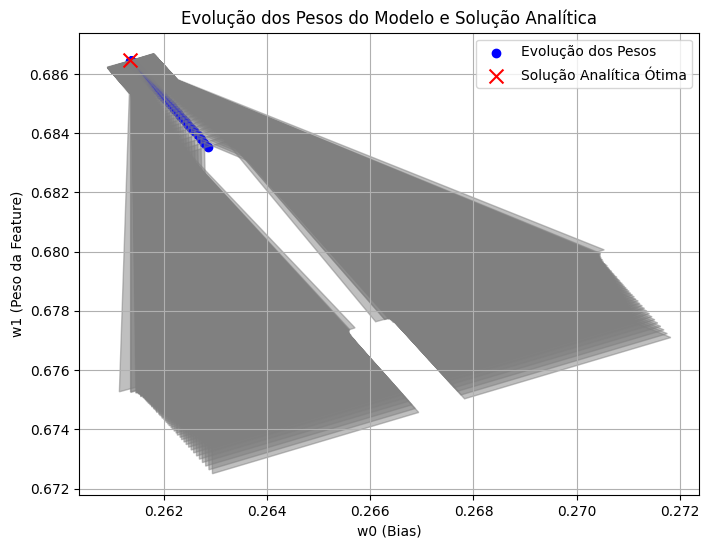

In [73]:
num_epochs = 100
learning_rate = 0.5

w0_list = []
w1_list = []

for epoch in range(num_epochs):
    inputs = x_train_bias
    target = y_train

    # forward - predict
    out = model(inputs)

    #loss cálculo da função de perda
    loss = torch.pow(out - target, 2).mean()
    # print('loss:',loss.data.numpy()) # Removido para evitar poluir o output

    # backward propagation - cálculo gradiente
    loss.backward()

    # Store current weights before update
    w0_list.append(model.weight.data[0][0].item())
    w1_list.append(model.weight.data[0][1].item())

    # gradiente descendente
    model.weight.data = model.weight.data - learning_rate * model.weight.grad.data

    # zeragem parâmetros próximo cálculo do gradiente
    model.weight.grad.data.zero_()

    # verbose
    if (epoch+1) % 20 == 0:
        print('Epoch[{}/{}], loss: {:.6f}'
              .format(epoch+1, num_epochs, loss.item()))


# Plotting the evolution of weights
plt.figure(figsize=(8, 6))
plt.scatter(w0_list, w1_list, c='blue', marker='o', label='Evolução dos Pesos')
w0_old = None
for i in range(len(w0_list)):
    if w0_old is not None:
        plt.arrow(w0_old, w1_old, w0_list[i] - w0_old, w1_list[i] - w1_old,
                  head_length=0.01, head_width=0.01, shape='full', color='gray',
                  length_includes_head=True, alpha=0.5)
    w0_old, w1_old = w0_list[i], w1_list[i]

# Add the optimal analytical solution
w_opt_0 = w_opt[0].item()
w_opt_1 = w_opt[1].item()
plt.scatter(w_opt_0, w_opt_1, c='red', marker='x', s=100, label='Solução Analítica Ótima')

plt.xlabel('w0 (Bias)')
plt.ylabel('w1 (Peso da Feature)')
plt.title('Evolução dos Pesos do Modelo e Solução Analítica')
plt.legend()
plt.grid(True)
plt.show()

## Ploting vectors

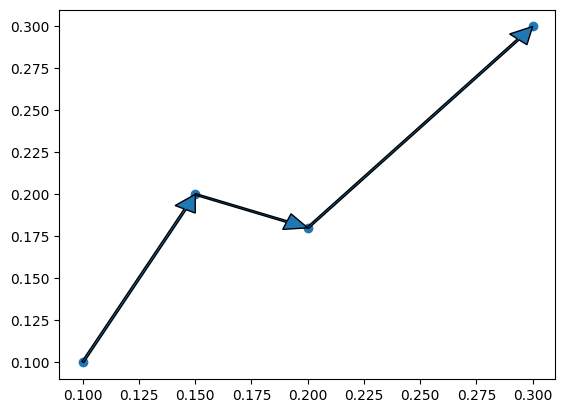

In [74]:
# Exemplo
w0_list = [0.1, 0.15, 0.2, 0.3]
w1_list = [0.1, 0.2, 0.18, 0.3]
plt.scatter(w0_list,w1_list)
w0_old = None
for (w0,w1) in zip(w0_list,w1_list):
    if w0_old:
        plt.arrow(w0_old, w1_old, w0-w0_old, w1-w1_old,
                  head_length=0.01,head_width=0.01,shape='full',
                  length_includes_head=True)
    w0_old,w1_old = w0,w1


# Aprendizados